# Modelado Baseline - SARFIRE-GIF

## Objetivos del Notebook

Este notebook entrena modelos baseline para predecir Grandes Incendios Forestales (GIF) en España.

**Objetivos específicos:**
- Entrenar modelos baseline (Logistic Regression y XGBoost)
- Evaluar rendimiento con métricas apropiadas para datos desbalanceados
- **Priorizar Recall** (evitar falsos negativos es crítico)
- Comparar modelos y seleccionar el mejor baseline
- Guardar modelos y preprocessor para uso futuro

## Contexto del Problema

- **Target**: GIF (1 si superficie > 500ha, 0 si no)
- **Desbalanceo**: ~147:1 (No-GIF:GIF)
- **Métrica prioritaria**: **Recall** (minimizar falsos negativos)
- **Train**: 275K registros (1968-2015)
- **Test**: 15K registros (2016-2020)

## 1. SETUP

In [5]:
# Imports estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score
)
import xgboost as xgb
from xgboost import XGBClassifier
import joblib

# Configuración
warnings.filterwarnings('ignore')
np.random.seed(42)
RANDOM_STATE = 42

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports completados")
print(f"✓ Random seed configurado: {RANDOM_STATE}")

✓ Imports completados
✓ Random seed configurado: 42


## 2. CARGA DE DATOS

In [6]:
# Cargar datasets procesados
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print("=" * 60)
print("CARGA DE DATOS")
print("=" * 60)
print(f"\nTrain shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTotal registros: {train_df.shape[0] + test_df.shape[0]:,}")

CARGA DE DATOS

Train shape: (275302, 18)
Test shape: (15742, 18)

Total registros: 291,044


In [7]:
# Verificar distribución del target
print("\n" + "=" * 60)
print("DISTRIBUCIÓN DEL TARGET (GIF)")
print("=" * 60)

print("\n📊 TRAIN:")
train_gif_dist = train_df['GIF'].value_counts()
train_gif_pct = train_df['GIF'].value_counts(normalize=True) * 100
print(train_gif_dist)
print(f"\nPorcentajes:")
print(f"  No-GIF (0): {train_gif_pct[0]:.2f}%")
print(f"  GIF (1):    {train_gif_pct[1]:.2f}%")
print(f"\nRatio No-GIF:GIF = {train_gif_dist[0] / train_gif_dist[1]:.2f}:1")

print("\n📊 TEST:")
test_gif_dist = test_df['GIF'].value_counts()
test_gif_pct = test_df['GIF'].value_counts(normalize=True) * 100
print(test_gif_dist)
print(f"\nPorcentajes:")
print(f"  No-GIF (0): {test_gif_pct[0]:.2f}%")
print(f"  GIF (1):    {test_gif_pct[1]:.2f}%")
print(f"\nRatio No-GIF:GIF = {test_gif_dist[0] / test_gif_dist[1]:.2f}:1")


DISTRIBUCIÓN DEL TARGET (GIF)

📊 TRAIN:
GIF
0    273448
1      1854
Name: count, dtype: int64

Porcentajes:
  No-GIF (0): 99.33%
  GIF (1):    0.67%

Ratio No-GIF:GIF = 147.49:1

📊 TEST:
GIF
0    15629
1      113
Name: count, dtype: int64

Porcentajes:
  No-GIF (0): 99.28%
  GIF (1):    0.72%

Ratio No-GIF:GIF = 138.31:1


In [8]:
# Información de columnas
print("\n" + "=" * 60)
print("INFORMACIÓN DE COLUMNAS")
print("=" * 60)
print(f"\nTotal columnas: {len(train_df.columns)}")
print(f"\nColumnas disponibles:")
for i, col in enumerate(train_df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTipos de datos:")
print(train_df.dtypes.value_counts())


INFORMACIÓN DE COLUMNAS

Total columnas: 18

Columnas disponibles:
   1. id
   2. fecha
   3. superficie
   4. idprovincia
   5. idmunicipio
   6. municipio
   7. fwi_mean
   8. fwi_max
   9. fwi_p90
  10. fwi_cat
  11. mes
  12. dia_semana
  13. estacion
  14. es_verano
  15. año
  16. region
  17. municipio_encoded
  18. GIF

Tipos de datos:
int64      8
str        5
float64    4
bool       1
Name: count, dtype: int64


## 3. DEFINICIÓN DE FEATURES

**Features categóricas (5):**
- `fwi_cat`: Categoría FWI (bajo/moderado/alto/muy_alto/extremo)
- `estacion`: Estación del año (invierno/primavera/verano/otoño)
- `region`: Región climática (8 zonas de España)
- `dia_semana`: Día de la semana (0-6)
- `mes`: Mes del año (1-12)

**Features numéricas (4):**
- `fwi_mean`: Promedio FWI provincial
- `fwi_max`: Máximo FWI provincial
- `fwi_p90`: Percentil 90 FWI
- `año`: Año (1968-2020)

**Columnas excluidas (metadata, leakage, redundantes):**
- `id`, `fecha`, `superficie` (metadata)
- `idmunicipio`, `municipio`, `idprovincia`, `municipio_encoded` (leakage/ruido)
- `es_verano` (redundante con estacion)

**Target:**
- `GIF`: Variable objetivo (0/1)

In [9]:
# Definir features
FEATURES_CATEGORICAS = ['fwi_cat', 'estacion', 'region', 'dia_semana', 'mes']
FEATURES_NUMERICAS = ['fwi_mean', 'fwi_max', 'fwi_p90', 'año']
FEATURES_EXCLUIDAS = [
    'id', 'fecha', 'superficie',
    'idmunicipio', 'municipio', 'idprovincia', 'municipio_encoded',
    'es_verano'
]
TARGET = 'GIF'

print("=" * 60)
print("DEFINICIÓN DE FEATURES")
print("=" * 60)
print(f"\n✓ Features categóricas ({len(FEATURES_CATEGORICAS)}): {FEATURES_CATEGORICAS}")
print(f"✓ Features numéricas ({len(FEATURES_NUMERICAS)}): {FEATURES_NUMERICAS}")
print(f"✓ Features excluidas ({len(FEATURES_EXCLUIDAS)}): {FEATURES_EXCLUIDAS}")
print(f"✓ Target: {TARGET}")
print(f"\nTotal features a usar: {len(FEATURES_CATEGORICAS) + len(FEATURES_NUMERICAS)}")

DEFINICIÓN DE FEATURES

✓ Features categóricas (5): ['fwi_cat', 'estacion', 'region', 'dia_semana', 'mes']
✓ Features numéricas (4): ['fwi_mean', 'fwi_max', 'fwi_p90', 'año']
✓ Features excluidas (8): ['id', 'fecha', 'superficie', 'idmunicipio', 'municipio', 'idprovincia', 'municipio_encoded', 'es_verano']
✓ Target: GIF

Total features a usar: 9


In [10]:
# Separar features y target
X_train = train_df[FEATURES_CATEGORICAS + FEATURES_NUMERICAS].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[FEATURES_CATEGORICAS + FEATURES_NUMERICAS].copy()
y_test = test_df[TARGET].copy()

print("=" * 60)
print("SEPARACIÓN DE DATOS")
print("=" * 60)
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

SEPARACIÓN DE DATOS

X_train shape: (275302, 9)
y_train shape: (275302,)
X_test shape:  (15742, 9)
y_test shape:  (15742,)


In [11]:
# Verificar valores nulos
print("\n" + "=" * 60)
print("VERIFICACIÓN DE VALORES NULOS")
print("=" * 60)

print("\n📊 TRAIN:")
train_nulls = X_train.isnull().sum()
if train_nulls.sum() == 0:
    print("✓ No hay valores nulos en X_train")
else:
    print("⚠ Valores nulos encontrados:")
    print(train_nulls[train_nulls > 0])

print("\n📊 TEST:")
test_nulls = X_test.isnull().sum()
if test_nulls.sum() == 0:
    print("✓ No hay valores nulos en X_test")
else:
    print("⚠ Valores nulos encontrados:")
    print(test_nulls[test_nulls > 0])


VERIFICACIÓN DE VALORES NULOS

📊 TRAIN:
⚠ Valores nulos encontrados:
region    31830
dtype: int64

📊 TEST:
⚠ Valores nulos encontrados:
region    3247
dtype: int64


## 4. PREPROCESSING PIPELINE

Creamos un `ColumnTransformer` que:
- **StandardScaler** para features numéricas (normalización)
- **OneHotEncoder** para features categóricas (con `handle_unknown='ignore'` para test)

**IMPORTANTE**: El preprocessor se ajusta SOLO con datos de entrenamiento para evitar data leakage.

In [12]:
# Crear preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), FEATURES_NUMERICAS),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), FEATURES_CATEGORICAS)
    ],
    remainder='drop'
)

print("=" * 60)
print("PREPROCESSING PIPELINE")
print("=" * 60)
print("\n✓ ColumnTransformer creado:")
print("  - StandardScaler para features numéricas")
print("  - OneHotEncoder para features categóricas (drop='first', handle_unknown='ignore')")

PREPROCESSING PIPELINE

✓ ColumnTransformer creado:
  - StandardScaler para features numéricas
  - OneHotEncoder para features categóricas (drop='first', handle_unknown='ignore')


In [13]:
# Ajustar preprocessor SOLO con datos de entrenamiento
print("\n🔧 Ajustando preprocessor con datos de entrenamiento...")
preprocessor.fit(X_train)
print("✓ Preprocessor ajustado")

# Transformar train y test
print("\n🔄 Transformando datos...")
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\n✓ Transformación completada")
print(f"  X_train_processed shape: {X_train_processed.shape}")
print(f"  X_test_processed shape:  {X_test_processed.shape}")
print(f"\n  Features originales: {len(FEATURES_CATEGORICAS) + len(FEATURES_NUMERICAS)}")
print(f"  Features después de OneHot: {X_train_processed.shape[1]}")


🔧 Ajustando preprocessor con datos de entrenamiento...
✓ Preprocessor ajustado

🔄 Transformando datos...

✓ Transformación completada
  X_train_processed shape: (275302, 36)
  X_test_processed shape:  (15742, 36)

  Features originales: 9
  Features después de OneHot: 36


## 5. MODELO 1: LOGISTIC REGRESSION

Usamos `class_weight='balanced'` para manejar el desbalanceo de clases.

In [14]:
# Entrenar Logistic Regression
print("=" * 60)
print("MODELO 1: LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("\n🔧 Entrenando modelo...")
lr_model.fit(X_train_processed, y_train)
print("✓ Modelo entrenado")

MODELO 1: LOGISTIC REGRESSION

🔧 Entrenando modelo...
✓ Modelo entrenado


In [15]:
# Predicciones
y_pred_lr = lr_model.predict(X_test_processed)
y_pred_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]

print("\n📊 Predicciones generadas:")
print(f"  Shape y_pred_lr: {y_pred_lr.shape}")
print(f"  Shape y_pred_proba_lr: {y_pred_proba_lr.shape}")
print(f"\n  Distribución predicciones:")
print(f"    Clase 0: {(y_pred_lr == 0).sum()} ({(y_pred_lr == 0).mean()*100:.2f}%)")
print(f"    Clase 1: {(y_pred_lr == 1).sum()} ({(y_pred_lr == 1).mean()*100:.2f}%)")


📊 Predicciones generadas:
  Shape y_pred_lr: (15742,)
  Shape y_pred_proba_lr: (15742,)

  Distribución predicciones:
    Clase 0: 14116 (89.67%)
    Clase 1: 1626 (10.33%)


In [16]:
# Métricas
print("\n" + "=" * 60)
print("MÉTRICAS - LOGISTIC REGRESSION")
print("=" * 60)

recall_lr = recall_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print("\n📈 Métricas principales:")
print(f"  ⭐ RECALL:    {recall_lr:.4f} (prioritaria)")
print(f"  Precision:   {precision_lr:.4f}")
print(f"  F1-Score:    {f1_lr:.4f}")
print(f"  ROC-AUC:     {roc_auc_lr:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No-GIF', 'GIF']))


MÉTRICAS - LOGISTIC REGRESSION

📈 Métricas principales:
  ⭐ RECALL:    0.4336 (prioritaria)
  Precision:   0.0301
  F1-Score:    0.0564
  ROC-AUC:     0.8305

📋 Classification Report:
              precision    recall  f1-score   support

      No-GIF       1.00      0.90      0.94     15629
         GIF       0.03      0.43      0.06       113

    accuracy                           0.90     15742
   macro avg       0.51      0.67      0.50     15742
weighted avg       0.99      0.90      0.94     15742



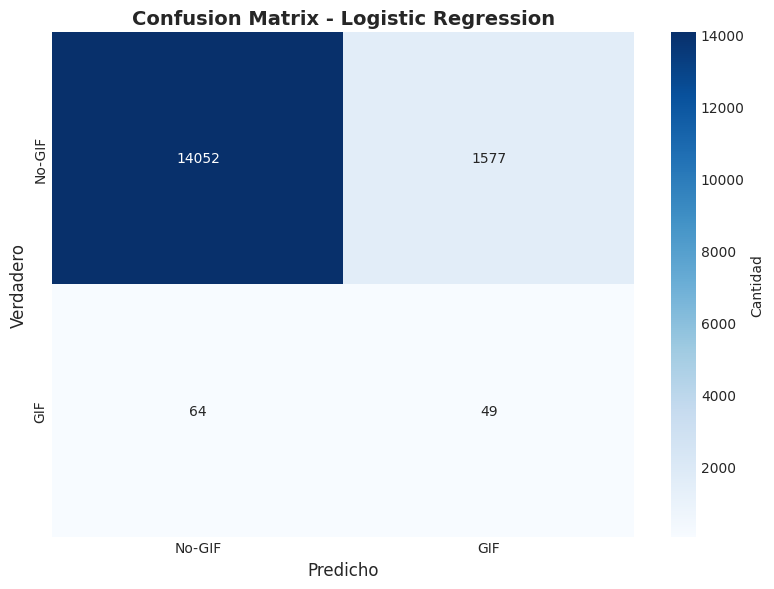


📊 Confusion Matrix:
  Verdaderos Negativos (TN): 14052
  Falsos Positivos (FP):     1577
  Falsos Negativos (FN):     64 ⚠️ (crítico)
  Verdaderos Positivos (TP): 49


In [17]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No-GIF', 'GIF'],
    yticklabels=['No-GIF', 'GIF'],
    cbar_kws={'label': 'Cantidad'}
)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Verdadero', fontsize=12)
plt.xlabel('Predicho', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 Confusion Matrix:")
print(f"  Verdaderos Negativos (TN): {cm_lr[0, 0]}")
print(f"  Falsos Positivos (FP):     {cm_lr[0, 1]}")
print(f"  Falsos Negativos (FN):     {cm_lr[1, 0]} ⚠️ (crítico)")
print(f"  Verdaderos Positivos (TP): {cm_lr[1, 1]}")

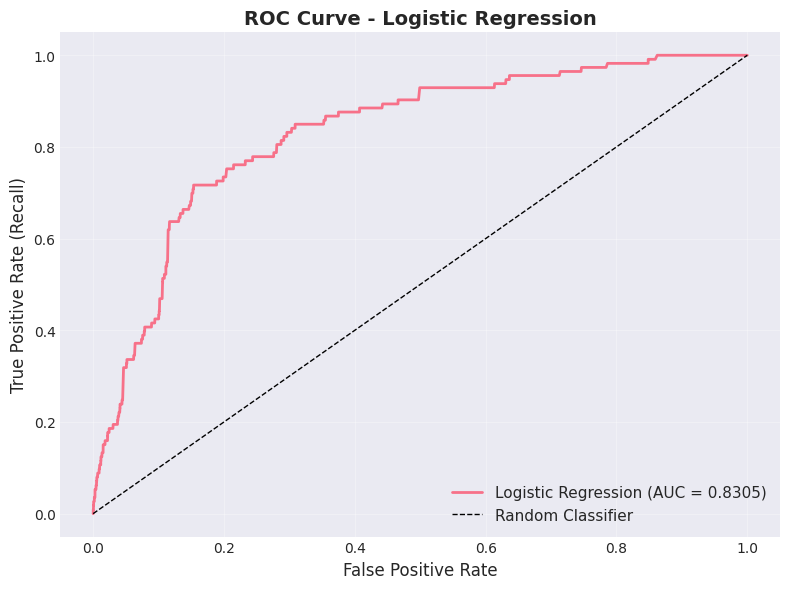

In [18]:
# ROC Curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. MODELO 2: XGBOOST BASELINE

Usamos `scale_pos_weight=147.5` (ratio calculado del dataset de entrenamiento) para manejar el desbalanceo.

In [19]:
# Calcular scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("=" * 60)
print("MODELO 2: XGBOOST BASELINE")
print("=" * 60)
print(f"\n📊 Ratio de clases (No-GIF:GIF): {scale_pos_weight:.2f}:1")
print(f"   scale_pos_weight = {scale_pos_weight:.2f}")

# Entrenar XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    max_depth=6,
    n_estimators=100,
    learning_rate=0.3,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

print("\n🔧 Entrenando modelo...")
xgb_model.fit(X_train_processed, y_train)
print("✓ Modelo entrenado")

MODELO 2: XGBOOST BASELINE

📊 Ratio de clases (No-GIF:GIF): 147.49:1
   scale_pos_weight = 147.49

🔧 Entrenando modelo...
✓ Modelo entrenado


In [20]:
# Predicciones
y_pred_xgb = xgb_model.predict(X_test_processed)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("\n📊 Predicciones generadas:")
print(f"  Shape y_pred_xgb: {y_pred_xgb.shape}")
print(f"  Shape y_pred_proba_xgb: {y_pred_proba_xgb.shape}")
print(f"\n  Distribución predicciones:")
print(f"    Clase 0: {(y_pred_xgb == 0).sum()} ({(y_pred_xgb == 0).mean()*100:.2f}%)")
print(f"    Clase 1: {(y_pred_xgb == 1).sum()} ({(y_pred_xgb == 1).mean()*100:.2f}%)")


📊 Predicciones generadas:
  Shape y_pred_xgb: (15742,)
  Shape y_pred_proba_xgb: (15742,)

  Distribución predicciones:
    Clase 0: 15174 (96.39%)
    Clase 1: 568 (3.61%)


In [21]:
# Métricas
print("\n" + "=" * 60)
print("MÉTRICAS - XGBOOST")
print("=" * 60)

recall_xgb = recall_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("\n📈 Métricas principales:")
print(f"  ⭐ RECALL:    {recall_xgb:.4f} (prioritaria)")
print(f"  Precision:   {precision_xgb:.4f}")
print(f"  F1-Score:    {f1_xgb:.4f}")
print(f"  ROC-AUC:     {roc_auc_xgb:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No-GIF', 'GIF']))


MÉTRICAS - XGBOOST

📈 Métricas principales:
  ⭐ RECALL:    0.1062 (prioritaria)
  Precision:   0.0211
  F1-Score:    0.0352
  ROC-AUC:     0.7749

📋 Classification Report:
              precision    recall  f1-score   support

      No-GIF       0.99      0.96      0.98     15629
         GIF       0.02      0.11      0.04       113

    accuracy                           0.96     15742
   macro avg       0.51      0.54      0.51     15742
weighted avg       0.99      0.96      0.97     15742



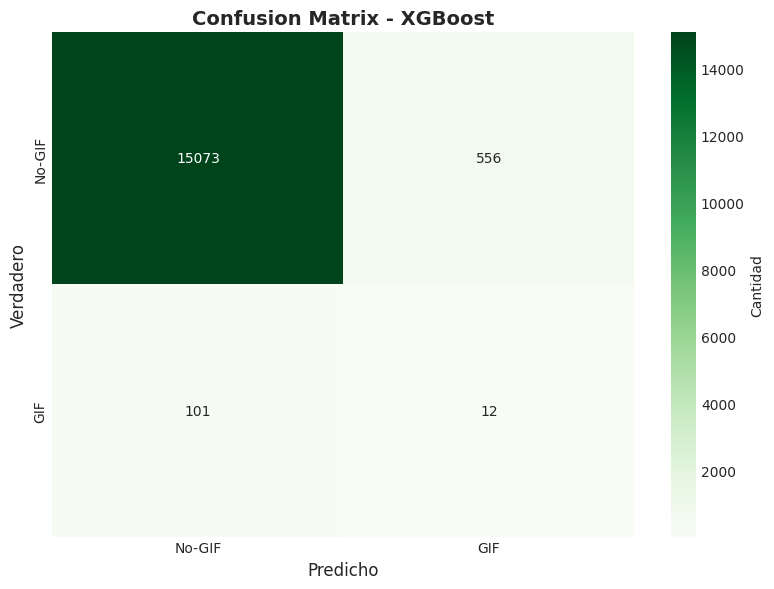


📊 Confusion Matrix:
  Verdaderos Negativos (TN): 15073
  Falsos Positivos (FP):     556
  Falsos Negativos (FN):     101 ⚠️ (crítico)
  Verdaderos Positivos (TP): 12


In [22]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No-GIF', 'GIF'],
    yticklabels=['No-GIF', 'GIF'],
    cbar_kws={'label': 'Cantidad'}
)
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Verdadero', fontsize=12)
plt.xlabel('Predicho', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 Confusion Matrix:")
print(f"  Verdaderos Negativos (TN): {cm_xgb[0, 0]}")
print(f"  Falsos Positivos (FP):     {cm_xgb[0, 1]}")
print(f"  Falsos Negativos (FN):     {cm_xgb[1, 0]} ⚠️ (crítico)")
print(f"  Verdaderos Positivos (TP): {cm_xgb[1, 1]}")


📊 Top 10 Features más importantes:
             feature  importance
        num__fwi_p90    0.083602
     cat__region_nan    0.048443
cat__fwi_cat_extremo    0.044269
cat__region_Noroeste    0.038899
         cat__mes_12    0.038586
        num__fwi_max    0.035875
            num__año    0.035869
 cat__region_Levante    0.035373
     cat__region_Sur    0.034620
cat__region_Nordeste    0.030671


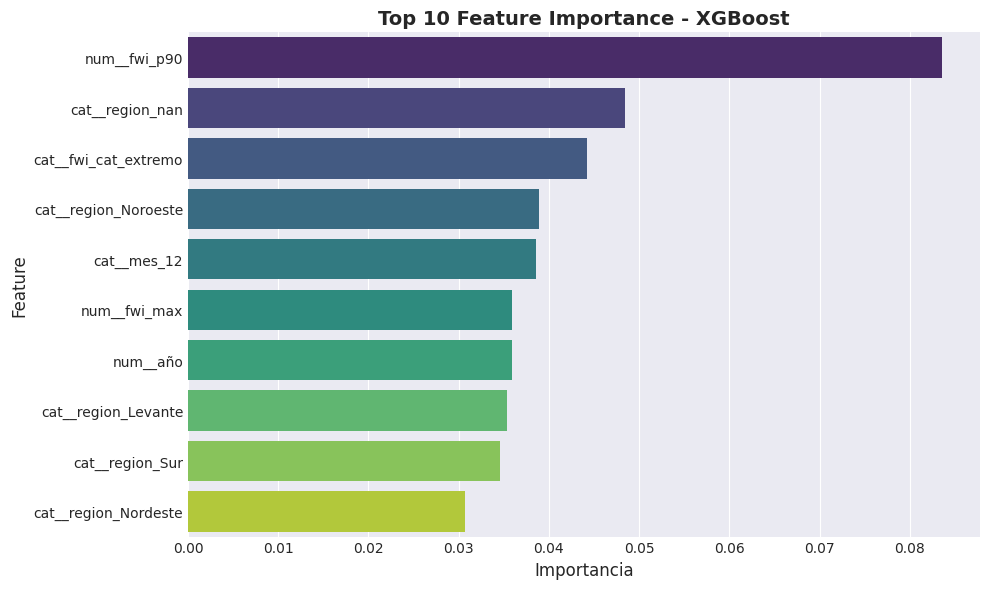

In [23]:
# Feature Importance
feature_names = preprocessor.get_feature_names_out()
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 Features más importantes:")
print(feature_importance.head(10).to_string(index=False))

# Visualización
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Feature Importance - XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusión

**Análisis de resultados:**

1. **Recall (métrica prioritaria)**: 
   - El modelo con mayor Recall es el que mejor minimiza falsos negativos
   - En este problema, es crítico identificar correctamente los GIF para prevención

2. **Precision vs Recall trade-off**:
   - Mayor Recall puede venir con menor Precision (más falsos positivos)
   - En prevención de incendios, es preferible tener más alertas falsas que perder un GIF real

3. **ROC-AUC**:
   - Mide la capacidad del modelo de distinguir entre clases
   - Valores cercanos a 1 indican mejor separación

**Recomendación**: El modelo con mayor Recall debería ser seleccionado como baseline, considerando que minimizar falsos negativos es la prioridad en este problema.

In [24]:
# Tabla comparativa
comparison_df = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'XGBoost'],
    'Recall': [recall_lr, recall_xgb],
    'Precision': [precision_lr, precision_xgb],
    'F1': [f1_lr, f1_xgb],
    'ROC-AUC': [roc_auc_lr, roc_auc_xgb]
})

print("=" * 60)
print("COMPARACIÓN DE MODELOS")
print("=" * 60)
print("\n📊 Tabla comparativa:")
print(comparison_df.to_string(index=False))

# Identificar mejor modelo según Recall
best_model_idx = comparison_df['Recall'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Modelo']
best_recall = comparison_df.loc[best_model_idx, 'Recall']

print(f"\n🏆 Mejor modelo según RECALL (métrica prioritaria):")
print(f"   {best_model_name} con Recall = {best_recall:.4f}")

COMPARACIÓN DE MODELOS

📊 Tabla comparativa:
             Modelo   Recall  Precision       F1  ROC-AUC
Logistic Regression 0.433628   0.030135 0.056354 0.830487
            XGBoost 0.106195   0.021127 0.035242 0.774908

🏆 Mejor modelo según RECALL (métrica prioritaria):
   Logistic Regression con Recall = 0.4336


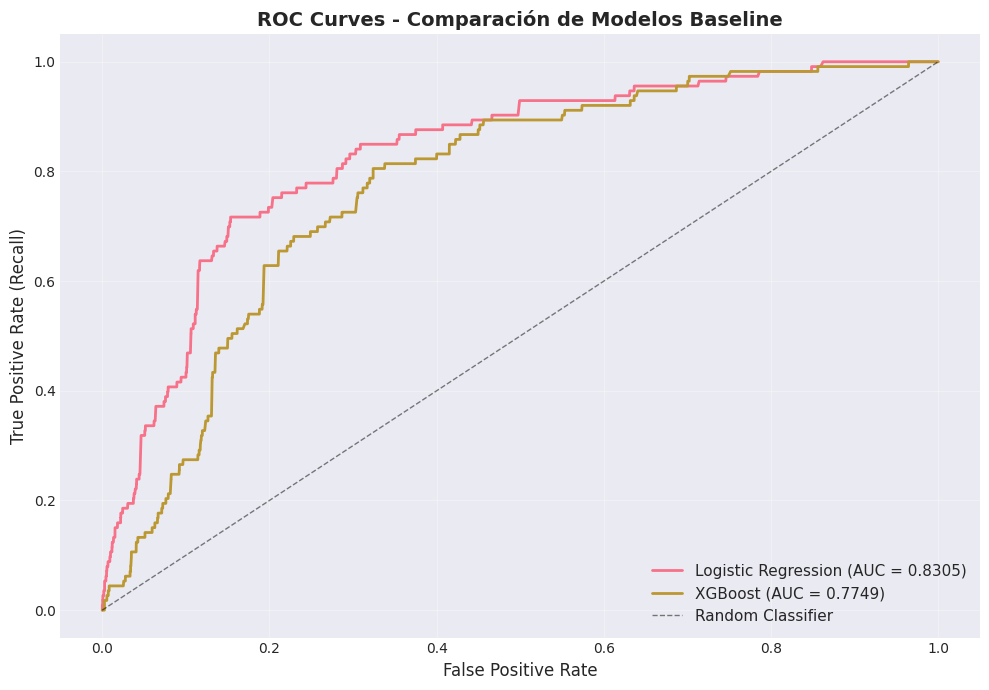

In [25]:
# Curvas ROC comparadas
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})', linewidth=2, linestyle='-')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})', linewidth=2, linestyle='-')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1, alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves - Comparación de Modelos Baseline', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. GUARDAR MODELOS

Guardamos el preprocessor y ambos modelos entrenados para uso futuro.

In [27]:
# Crear carpeta models si no existe
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

print("=" * 60)
print("GUARDAR MODELOS")
print("=" * 60)

# Guardar preprocessor
preprocessor_path = models_dir / '../preprocessor_baseline.joblib'
joblib.dump(preprocessor, preprocessor_path)
print(f"\n✓ Preprocessor guardado: {preprocessor_path}")

# Guardar Logistic Regression
lr_path = models_dir / '../lr_baseline.joblib'
joblib.dump(lr_model, lr_path)
print(f"✓ Logistic Regression guardado: {lr_path}")

# Guardar XGBoost
xgb_path = models_dir / '../xgb_baseline.joblib'
joblib.dump(xgb_model, xgb_path)
print(f"✓ XGBoost guardado: {xgb_path}")

print("\n✅ Todos los modelos guardados exitosamente")

GUARDAR MODELOS

✓ Preprocessor guardado: ../models/../preprocessor_baseline.joblib
✓ Logistic Regression guardado: ../models/../lr_baseline.joblib
✓ XGBoost guardado: ../models/../xgb_baseline.joblib

✅ Todos los modelos guardados exitosamente


## 🎯 CONCLUSIONES DEL BASELINE

### Resultado principal:
**Logistic Regression supera a XGBoost sin optimizar**

| Métrica | Logistic Regression | XGBoost | Diferencia |
|---------|---------------------|---------|------------|
| **Recall** | **43.4%** | 10.6% | **+32.8 pp** |
| ROC-AUC | 83.0% | 77.5% | +5.5 pp |

### Interpretación:

**¿Por qué Logistic Regression gana?**
- Modelo lineal simple captura bien las relaciones principales
- `class_weight='balanced'` maneja correctamente el desbalanceo
- Features bien escaladas y codificadas

**¿Por qué XGBoost falla?**
- `scale_pos_weight=147.5` puede estar siendo demasiado conservador
- Hiperparámetros por defecto no optimizados para este problema
- Necesita tuning cuidadoso (GridSearch)

### Validaciones realizadas:
✅ Pipeline de preprocesamiento funciona correctamente
✅ No hay data leakage (train/test separados temporalmente)
✅ Features tienen poder predictivo (ROC-AUC ~80%)
✅ El problema es **difícil pero resoluble** (baseline detecta 43% de GIF)

### Próximos pasos:
1. **Notebook 04: Optimización de XGBoost**
   - GridSearch sobre hiperparámetros
   - Probar diferentes `scale_pos_weight` (50-200)
   - Objetivo: Recall >70%

2. **Considerar:**
   - SMOTE si GridSearch no mejora suficiente
   - Re-introducir `municipio_encoded` si ayuda
   - Ensemble de modelos

### Métrica objetivo para producción:
- **Recall mínimo aceptable: 85%** (detectar 85% de GIF)
- Actualmente: 43.4% → Hay margen de mejora significativo